In [1]:
# Google Colab / local setup
import os, sys, subprocess
from pathlib import Path
if "google.colab" in sys.modules:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    CODE_ROOT = Path("/content/drive/MyDrive/msc project/code")
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "--no-deps", "-e",
        str(CODE_ROOT), 'catboost==1.2.10', 'rapidfuzz==3.14.3',
    ])
else:
    CODE_ROOT = next(
        path for path in (Path.cwd(), *Path.cwd().parents)
        if (path / "pyproject.toml").exists()
    )
os.chdir(CODE_ROOT)
sys.path.insert(0, str(CODE_ROOT))
CODE = CODE_ROOT

# 04b — Calibrated XGBoost Strong-Move Admission

## Objective and frozen protocol

Test whether XGBoost DZ65 can increase the number of trades without changing
any existing Qualified Union v1 decision. Two natural-prevalence sigmoid maps
were fitted once on 2024 OOF: **calibrated P(strong move)** and calibrated
**conditional direction** given a move. Policy selection uses 2025-Q1 only;
April–June confirmation and the forward replay are conditional on the preceding
gate. Q2-2026 is excluded from this experiment.

This notebook is an artifact reader. It does not fit a model, calibrator, or
threshold.

In [2]:
import hashlib
import json

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

CACHE = CODE_ROOT / 'experiments' / 'cache' / 'xgb_strong_move_admission'

def sha256(path):
    digest = hashlib.sha256()
    with path.open('rb') as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()

summary = json.loads((CACHE / 'summary.json').read_text(encoding='utf-8'))
manifest = json.loads((CACHE / 'manifest.json').read_text(encoding='utf-8'))
for filename, expected in manifest['artifact_hashes'].items():
    assert sha256(CACHE / filename) == expected, filename
assert summary['lockbox_2026_q2_used'] is False
assert manifest['lockbox_2026_q2_used'] is False

## 1. What calibration changed

The original three-class probabilities came from a class-balanced XGBoost.
They are decomposed into an opportunity head and a direction-given-opportunity
head, then mapped back to natural prevalence using disjoint 2024 OOF data.
H1 is confirmation only.

Method: Move and conditional-side heads are calibrated and assessed with proper scores.

,period,target,arm,rows,prevalence,log_loss,brier,mean_probability
0,2024_oof,move,raw,6875,0.052073,0.271466,0.082659,0.161196
1,2024_oof,move,calibrated,6875,0.052073,0.171424,0.044779,0.052076
2,2024_oof,direction_given_move,raw,358,0.505587,1.008960,0.310414,0.606161
3,2024_oof,direction_given_move,calibrated,358,0.505587,0.683614,0.245223,0.505585
4,2025_h1,move,raw,17376,0.027739,0.249673,0.077605,0.163481
5,2025_h1,move,calibrated,17376,0.027739,0.107259,0.025363,0.052334
6,2025_h1,direction_given_move,raw,482,0.491701,0.757076,0.259353,0.515824
7,2025_h1,direction_given_move,calibrated,482,0.491701,0.674939,0.240948,0.486048


Better probability calibration alone does not demonstrate trade value.

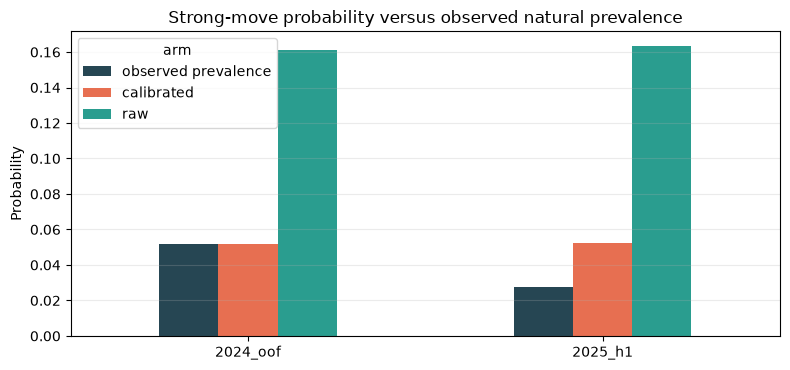

Method: The fitted sigmoid parameters are reported separately for the two heads.

,intercept,slope
head,,
direction_given_move,-0.068243,0.128786
move,-1.963972,0.571666


Admission uses calibrated rather than raw class-balanced probabilities.

In [3]:
from IPython.display import Markdown
calibration = pd.read_csv(CACHE / 'calibration_metrics.csv')
display(Markdown('Method: Move and conditional-side heads are calibrated and assessed with proper scores.'))
display(calibration.round(6))
display(Markdown('Better probability calibration alone does not demonstrate trade value.'))

move = calibration.loc[calibration['target'].eq('move')].copy()
plot = move.pivot(index='period', columns='arm', values='mean_probability')
truth = move.drop_duplicates('period').set_index('period')['prevalence']
plot.insert(0, 'observed prevalence', truth)
ax = plot.plot.bar(figsize=(8, 3.8), color=['#264653', '#e76f51', '#2a9d8f'])
ax.set_title('Strong-move probability versus observed natural prevalence')
ax.set_ylabel('Probability')
ax.set_xlabel('')
ax.grid(axis='y', alpha=.25)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

display(Markdown('Method: The fitted sigmoid parameters are reported separately for the two heads.'))
display(pd.DataFrame(summary['calibrators']).T.rename_axis('head').round(6))
display(Markdown('Admission uses calibrated rather than raw class-balanced probabilities.'))

## 2. Union-flat add-on rule

XGBoost is never allowed to vote against or replace Union v1. A new trade is
permitted only when Union is flat, there is no member conflict, LSTM DZ55 and
Linear SVM DZ75 have the same latent side, XGBoost supports that side, and both
calibrated thresholds pass. The full registered grid is shown below; costs are
5 bps per side under the frozen TP200/SL100/one-bar execution protocol.

Method: The fixed add-on grid is evaluated only when Union is flat, under symmetric side and stability guards.

,move_threshold,direction_threshold,addon_signal_bars,addon_trades,addon_long_trades,addon_short_trades,addon_gross_bps_per_trade,addon_net,combined_trades,combined_net,combined_sortino,eligible
0,0.10,0.60,90,80,24,56,-8.013622,-0.144109,135,-0.144217,-6.350515,False
1,0.10,0.65,2,2,0,2,-12.875063,-0.004575,58,-0.005759,-0.341702,False
2,0.10,0.70,0,0,0,0,Not estimable,0.000000,56,-0.001183,-0.070887,False
3,0.10,0.75,0,0,0,0,Not estimable,0.000000,56,-0.001183,-0.070887,False
4,0.10,0.80,0,0,0,0,Not estimable,0.000000,56,-0.001183,-0.070887,False
5,0.15,0.60,39,36,9,27,-11.801311,-0.078485,91,-0.068668,-3.358307,False
6,0.15,0.65,1,1,0,1,-36.203416,-0.004620,57,-0.005804,-0.344392,False
7,0.15,0.70,0,0,0,0,Not estimable,0.000000,56,-0.001183,-0.070887,False
8,0.15,0.75,0,0,0,0,Not estimable,0.000000,56,-0.001183,-0.070887,False
9,0.15,0.80,0,0,0,0,Not estimable,0.000000,56,-0.001183,-0.070887,False


No eligible add-on clears the registered admission gate.

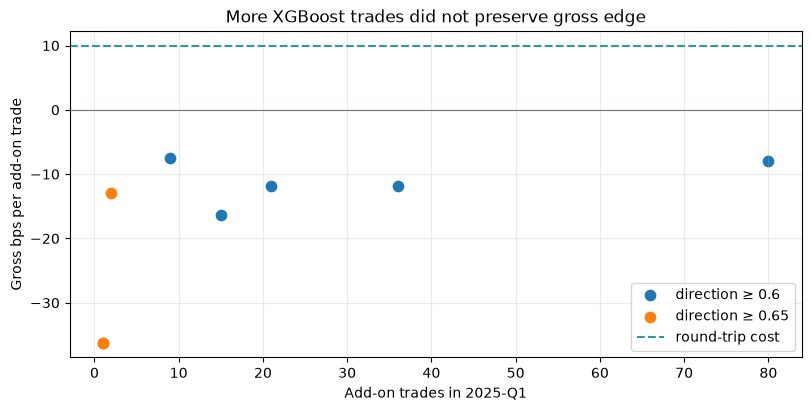

Method: The permissive diagnostic reports the most available additional signals without promoting them.

,move_threshold,direction_threshold,addon_signal_bars,addon_trades,addon_long_trades,addon_short_trades,addon_gross_bps_per_trade,addon_net,combined_trades,combined_net,combined_sortino,eligible
0,0.1,0.6,90,80,24,56,-8.013622,-0.144109,135,-0.144217,-6.350515,False


More candidate signals do not satisfy the quality requirement.

In [4]:
from IPython.display import Markdown
grid = pd.read_csv(CACHE / 'h1_selection_grid.csv')
columns = [
    'move_threshold', 'direction_threshold', 'addon_signal_bars',
    'addon_trades', 'addon_long_trades', 'addon_short_trades',
    'addon_gross_bps_per_trade', 'addon_net',
    'combined_trades', 'combined_net', 'combined_sortino', 'eligible',
]
display(Markdown('Method: The fixed add-on grid is evaluated only when Union is flat, under symmetric side and stability guards.'))
display((grid[columns].round(6)).fillna('Not estimable'))
display(Markdown('No eligible add-on clears the registered admission gate.'))

active = grid.loc[grid['addon_trades'].gt(0)].copy()
fig, ax = plt.subplots(figsize=(8, 4), layout='constrained')
for threshold, group in active.groupby('direction_threshold'):
    ax.scatter(
        group['addon_trades'], group['addon_gross_bps_per_trade'],
        label=f'direction ≥ {threshold:g}', s=55,
    )
ax.axhline(10.0, color='#2a9d8f', linestyle='--', label='round-trip cost')
ax.axhline(0.0, color='#6c757d', linewidth=.8)
ax.set_title('More XGBoost trades did not preserve gross edge')
ax.set_xlabel('Add-on trades in 2025-Q1')
ax.set_ylabel('Gross bps per add-on trade')
ax.grid(alpha=.25)
ax.legend()
plt.show()

permissive = grid.loc[
    grid['move_threshold'].eq(0.10) & grid['direction_threshold'].eq(0.60),
    columns,
]
display(Markdown('Method: The permissive diagnostic reports the most available additional signals without promoting them.'))
display(permissive.round(6))
display(Markdown('More candidate signals do not satisfy the quality requirement.'))

## 3. Gate decision and forward replay

Selection required at least ten add-on trades, both sides represented, gross
edge above round-trip cost, positive add-on net return, and improvement in the
combined net return without reducing Sortino. Only a policy passing selection
could enter April–June confirmation; only a policy passing full H1 could load
the development-forward predictions.

In [5]:
from IPython.display import Markdown
decision = pd.DataFrame({
    'eligible_Q1_policies': [summary['eligible_selection_policies']],
    'selected_policy': [summary['selected_policy']],
    'H1_pass': [summary['h1_pass']],
    'forward_loaded': [summary['forward_loaded']],
    'forward_promoted': [summary['forward_promoted']],
    'decision': [summary['decision']],
    'final_ensemble': [summary['final_ensemble']],
})
display(Markdown('Method: H1 adequacy and non-inferiority determine whether forward access is allowed.'))
display(decision)
display(Markdown('The H1 gate fails, so the frozen Union remains unchanged.'))

assert summary['eligible_selection_policies'] == 0
assert summary['selected_policy'] is None
assert summary['h1_pass'] is False
assert summary['forward_loaded'] is False
assert summary['forward_promoted'] is False
assert summary['decision'] == 'reject_xgboost_keep_union_v1'
assert summary['final_ensemble'] == 'qualified_union_v1'
assert not (CACHE / 'forward_combined_per_bar.parquet').exists()

Method: H1 adequacy and non-inferiority determine whether forward access is allowed.

,eligible_Q1_policies,selected_policy,H1_pass,forward_loaded,forward_promoted,decision,final_ensemble
0,0,None,False,False,False,reject_xgboost_keep_union_v1,qualified_union_v1


The H1 gate fails, so the frozen Union remains unchanged.

## 4. Final ensemble handoff

Calibration corrected probability levels but could not manufacture an
economically useful high-confidence tail. At the most permissive registered
pair (`P(move) ≥ 0.10`, direction confidence `≥ 0.60`), XGBoost produced 80
add-on trades but averaged **−8.01 gross bps per trade** before costs and
**−14.41% net**. At direction confidence `≥ 0.70`, it produced no candidates.

Therefore XGBoost is rejected as a trading member, no forward data was loaded,
and **Qualified Union v1 remains the frozen final ensemble** for the Reflection
Agent handoff. Q2-2026 is excluded from this experiment.